# Circular mitochondrial genome mapping with ID-based deduplication

This notebook:

1. Reads the attached sequence files.
2. **Removes duplicate records by sequence ID** (keeping the first occurrence of each ID).
3. Maps the remaining unique-ID reads to the circular mitochondrial assembly.
4. Calculates coverage and depth.
5. Writes a CSV table, a summary text file, and a coverage plot.

Input files expected in the same folder as this notebook:

- `Assembled_gbima.fasta`
- `merged_sequences.fasta`
- `fulldump.txt`
- `gap_1.txt`
- `gap_2.txt`
- `seqdumpddd.txt`

Notes:
- Deduplication here is **by sequence ID**, not by sequence string.
- Mapping tries forward and reverse-complement orientations.
- Mapping order is: exact circular match → Hamming distance up to 3 mismatches → local alignment rescue.


In [1]:

from pathlib import Path
from collections import defaultdict, Counter
import re, statistics, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import pairwise2


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:

BASE = Path('.')
REFERENCE_FILE = BASE / 'Assembled_gbima.fasta'
READ_FILES = [
    BASE / 'merged_sequences.fasta',
    BASE / 'fulldump.txt',
    BASE / 'gap_1.txt',
    BASE / 'gap_2.txt',
    BASE / 'seqdumpddd.txt',
]

OUTPUT_CSV = BASE / 'final_circular_dedup_by_id_mapping_results.csv'
OUTPUT_SUMMARY = BASE / 'final_circular_dedup_by_id_mapping_summary.txt'
OUTPUT_PLOT = BASE / 'final_circular_dedup_by_id_coverage_plot.png'


In [3]:

def parse_fasta(path):
    records = []
    seq_id = None
    seq_chunks = []
    with open(path) as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if seq_id is not None:
                    records.append((seq_id, ''.join(seq_chunks).upper()))
                seq_id = line[1:].strip()
                seq_chunks = []
            else:
                seq_chunks.append(re.sub(r'[^A-Za-z]', '', line))
        if seq_id is not None:
            records.append((seq_id, ''.join(seq_chunks).upper()))
    return records

def revcomp(seq):
    return seq.translate(str.maketrans('ACGTNacgtn', 'TGCANtgcan'))[::-1].upper()

def build_index(seq, k):
    idx = defaultdict(list)
    for i in range(len(seq) - k + 1):
        idx[seq[i:i+k]].append(i)
    return idx

def mismatches(a, b, max_mm=None):
    mm = 0
    for x, y in zip(a, b):
        if x != y:
            mm += 1
            if max_mm is not None and mm > max_mm:
                return mm
    return mm


In [4]:

reference_records = parse_fasta(REFERENCE_FILE)
assert len(reference_records) == 1, "Expected exactly one reference sequence"
reference_id, reference_seq = reference_records[0]
reference_len = len(reference_seq)
reference_circular = reference_seq + reference_seq

total_input_records = 0
unique_by_id = {}
duplicate_records_removed = Counter()
source_map = defaultdict(list)

for read_file in READ_FILES:
    records = parse_fasta(read_file)
    total_input_records += len(records)
    for full_header, seq in records:
        short_id = full_header.split()[0]
        source_map[short_id].append(read_file.name)
        if short_id not in unique_by_id:
            unique_by_id[short_id] = {
                'full_header': full_header,
                'sequence': seq,
                'source_first_seen': read_file.name,
            }
        else:
            duplicate_records_removed[short_id] += 1
            assert unique_by_id[short_id]['sequence'] == seq, f"Same ID but different sequence for {short_id}"

print("Reference length:", reference_len)
print("Total input records:", total_input_records)
print("Unique sequence IDs:", len(unique_by_id))
print("Duplicate records removed by ID:", sum(duplicate_records_removed.values()))


Reference length: 15954
Total input records: 6682
Unique sequence IDs: 4749
Duplicate records removed by ID: 1933


In [5]:

seed_lengths = [12, 37, 38, 50, 75]
index_by_len = {k: build_index(reference_circular, k) for k in seed_lengths}

parts_by_k = {
    1: [(0, 75), (75, 150)],
    2: [(0, 50), (50, 100), (100, 150)],
    3: [(0, 38), (38, 76), (76, 113), (113, 150)],
}

def circular_exact_start(query):
    pos = reference_circular.find(query, 0, reference_len + len(query) - 1)
    return None if pos == -1 else pos % reference_len

def circular_hamming_map(query, max_mm=3):
    exact = circular_exact_start(query)
    if exact is not None:
        return exact, 0

    for k in range(1, max_mm + 1):
        candidates = set()
        for a, b in parts_by_k[k]:
            seed = query[a:b]
            for p in index_by_len[len(seed)].get(seed, []):
                candidates.add((p - a) % reference_len)

        best = None
        for start in candidates:
            target = reference_circular[start:start + len(query)]
            mm = mismatches(query, target, k)
            if mm <= k:
                if best is None or mm < best[1] or (mm == best[1] and start < best[0]):
                    best = (start, mm)

        if best is not None:
            return best

    return None

def candidate_starts_from_seeds(query, step=20, k=12):
    counter = Counter()
    for offset in range(0, len(query) - k + 1, step):
        seed = query[offset:offset + k]
        for p in index_by_len[k].get(seed, []):
            counter[(p - offset) % reference_len] += 1
    return [start for start, _ in counter.most_common(20)]

def circular_local_map(query):
    best = None
    for orientation, q in [('forward', query), ('reverse', revcomp(query))]:
        starts = candidate_starts_from_seeds(q)
        for start in starts:
            window = reference_circular[start:start + len(q) + 8]
            alns = pairwise2.align.localms(window, q, 2, -1, -2, -0.5, one_alignment_only=True)
            if not alns:
                continue

            aligned_ref, aligned_query, score, begin, end = alns[0]
            ref_consumed = 0
            first_ref = None
            matches = 0
            mism = 0
            gaps = 0

            for ca, cb in zip(aligned_ref, aligned_query):
                query_active = (cb != '-')
                if query_active and first_ref is None:
                    first_ref = ref_consumed
                if ca != '-':
                    ref_consumed += 1
                if cb != '-':
                    if ca == '-':
                        gaps += 1
                    elif ca == cb:
                        matches += 1
                    else:
                        mism += 1
                elif ca != '-':
                    gaps += 1

            if first_ref is None:
                continue

            mapped_start = (start + first_ref) % reference_len
            identity = matches / len(q)

            if identity < 0.94:
                continue

            candidate = (score, identity, mapped_start, orientation, mism, gaps)
            if best is None or candidate > best:
                best = candidate

    if best is None:
        return None

    score, identity, mapped_start, orientation, mism, gaps = best
    return mapped_start, orientation, mism, gaps, score, identity


In [6]:

results = []

for seq_id, rec in unique_by_id.items():
    seq = rec['sequence']
    best = None

    for orientation, q in [('forward', seq), ('reverse', revcomp(seq))]:
        hm = circular_hamming_map(q, max_mm=3)
        if hm is not None:
            start, mm = hm
            method = 'circular_exact' if mm == 0 else f'circular_hamming_{mm}mm'
            candidate = (mm, start, orientation, method, q)
            if best is None or candidate < best:
                best = candidate

    if best is None:
        local = circular_local_map(seq)
        if local is not None:
            start, orientation, mism, gaps, score, identity = local
            q = seq if orientation == 'forward' else revcomp(seq)
            results.append({
                'seq_id': seq_id,
                'full_header': rec['full_header'],
                'source_first_seen': rec['source_first_seen'],
                'duplicate_instances_removed': duplicate_records_removed.get(seq_id, 0),
                'length': len(seq),
                'orientation': orientation,
                'start_1based': start + 1,
                'end_1based_circular': ((start + len(q) - 1) % reference_len) + 1,
                'method': 'circular_local',
                'mismatches': mism,
                'gaps_est': gaps,
                'local_score': score,
                'identity_est': identity,
                'sequence': seq,
            })
        else:
            results.append({
                'seq_id': seq_id,
                'full_header': rec['full_header'],
                'source_first_seen': rec['source_first_seen'],
                'duplicate_instances_removed': duplicate_records_removed.get(seq_id, 0),
                'length': len(seq),
                'orientation': '',
                'start_1based': '',
                'end_1based_circular': '',
                'method': 'unmapped',
                'mismatches': '',
                'gaps_est': '',
                'local_score': '',
                'identity_est': '',
                'sequence': seq,
            })
    else:
        mm, start, orientation, method, q = best
        results.append({
            'seq_id': seq_id,
            'full_header': rec['full_header'],
            'source_first_seen': rec['source_first_seen'],
            'duplicate_instances_removed': duplicate_records_removed.get(seq_id, 0),
            'length': len(seq),
            'orientation': orientation,
            'start_1based': start + 1,
            'end_1based_circular': ((start + len(q) - 1) % reference_len) + 1,
            'method': method,
            'mismatches': mm,
            'gaps_est': 0,
            'local_score': '',
            'identity_est': 1 - mm / len(q),
            'sequence': seq,
        })

mapping_df = pd.DataFrame(results)
mapping_df.head()


,seq_id,full_header,source_first_seen,duplicate_instances_removed,length,orientation,start_1based,end_1based_circular,method,mismatches,gaps_est,local_score,identity_est,sequence
0,gnl|SRA|SRR35113092.343249422.1,gnl|SRA|SRR35113092.343249422.1 E250004532L1C0...,merged_sequences.fasta,1,150,reverse,265,414,circular_exact,0,0,,1.0,TGATGAAGCTATAGCTTGAATAATAAAATATTTTATAGCTGCTTCT...
1,gnl|SRA|SRR35113092.329105605.1,gnl|SRA|SRR35113092.329105605.1 E250004532L1C0...,merged_sequences.fasta,1,150,reverse,357,506,circular_hamming_1mm,1,0,,0.993333,TTTAAGAATAATGTGATAGAAATAGCTGAATTGATTATATTTTTAT...
2,gnl|SRA|SRR35113092.285717147.1,gnl|SRA|SRR35113092.285717147.1 E250004532L1C0...,merged_sequences.fasta,1,150,reverse,841,990,circular_hamming_1mm,1,0,,0.993333,GTTCTGAATAATTATTCATTTAGGTAAGAATCCTAAGAATGGAGGT...
3,gnl|SRA|SRR35113092.232736294.1,gnl|SRA|SRR35113092.232736294.1 E200003969L1C0...,merged_sequences.fasta,1,150,reverse,262,411,circular_exact,0,0,,1.0,TGAAGCTATAGCTTGAATAATAAAATATTTTATAGCTGCTTCTGTT...
4,gnl|SRA|SRR35113092.193146472.1,gnl|SRA|SRR35113092.193146472.1 E200003969L1C0...,merged_sequences.fasta,1,150,reverse,844,993,circular_hamming_1mm,1,0,,0.993333,TGAGTTCTGAATAATTATTCATTTAGGTAAGAATCCTAAGAATGGA...


In [7]:

depth = np.zeros(reference_len, dtype=int)

for row in mapping_df.itertuples(index=False):
    if row.method == 'unmapped':
        continue
    start0 = int(row.start_1based) - 1
    for j in range(int(row.length)):
        depth[(start0 + j) % reference_len] += 1

covered_bp = int((depth > 0).sum())

zero_intervals = []
i = 0
while i < reference_len:
    if depth[i] == 0:
        j = i
        while j < reference_len and depth[j] == 0:
            j += 1
        zero_intervals.append((i + 1, j))
        i = j
    else:
        i += 1

sequence_counts = Counter(rec['sequence'] for rec in unique_by_id.values())
sequence_level_duplicate_total = sum(c - 1 for c in sequence_counts.values() if c > 1)
shared_sequence_string_count = sum(1 for c in sequence_counts.values() if c > 1)

summary = {
    'reference_length_bp': reference_len,
    'total_input_records': total_input_records,
    'unique_sequence_ids_after_dedup': len(unique_by_id),
    'duplicate_records_removed_by_id': int(sum(duplicate_records_removed.values())),
    'mapped_unique_ids': int((mapping_df['method'] != 'unmapped').sum()),
    'unmapped_unique_ids': int((mapping_df['method'] == 'unmapped').sum()),
    'circular_coverage_bp': covered_bp,
    'circular_coverage_percent': round(covered_bp / reference_len * 100, 4),
    'minimum_depth_unique_ids': int(depth.min()),
    'mean_depth_unique_ids': round(float(depth.mean()), 4),
    'maximum_depth_unique_ids': int(depth.max()),
    'zero_coverage_intervals_1based': zero_intervals,
    'mapping_method_counts': dict(Counter(mapping_df['method'])),
    'orientation_counts_mapped': dict(Counter(mapping_df.loc[mapping_df['method'] != 'unmapped', 'orientation'])),
    'unique_sequence_strings_among_unique_ids': len(sequence_counts),
    'extra_duplicate_sequences_by_content_among_unique_ids': int(sequence_level_duplicate_total),
    'number_of_sequence_strings_shared_by_multiple_unique_ids': int(shared_sequence_string_count),
}
summary


{'reference_length_bp': 15954,
 'total_input_records': 6682,
 'unique_sequence_ids_after_dedup': 4749,
 'duplicate_records_removed_by_id': 1933,
 'mapped_unique_ids': 4731,
 'unmapped_unique_ids': 18,
 'circular_coverage_bp': 15954,
 'circular_coverage_percent': 100.0,
 'minimum_depth_unique_ids': 2,
 'mean_depth_unique_ids': 44.481,
 'maximum_depth_unique_ids': 92,
 'zero_coverage_intervals_1based': [],
 'mapping_method_counts': {'circular_exact': 4112,
  'circular_hamming_1mm': 395,
  'circular_hamming_2mm': 95,
  'circular_hamming_3mm': 76,
  'circular_local': 53,
  'unmapped': 18},
 'orientation_counts_mapped': {'reverse': 2487, 'forward': 2244},
 'unique_sequence_strings_among_unique_ids': 3647,
 'extra_duplicate_sequences_by_content_among_unique_ids': 1102,
 'number_of_sequence_strings_shared_by_multiple_unique_ids': 712}

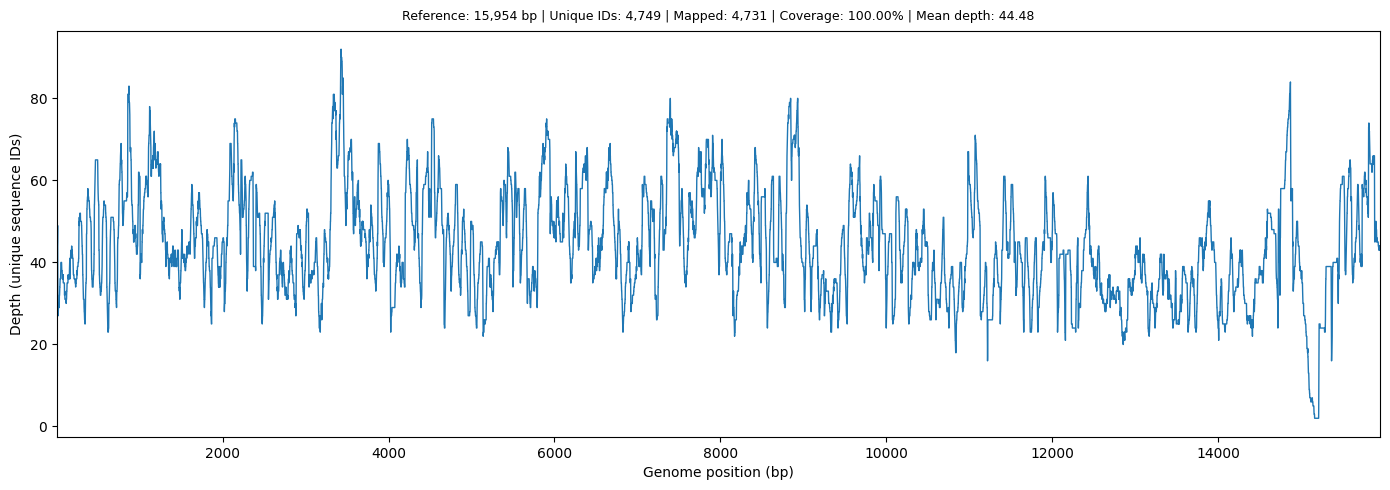

Wrote:
 - final_circular_dedup_by_id_mapping_results.csv
 - final_circular_dedup_by_id_mapping_summary.txt
 - final_circular_dedup_by_id_coverage_plot.png


In [8]:

mapping_df.to_csv(OUTPUT_CSV, index=False)

with open(OUTPUT_SUMMARY, 'w') as handle:
    for key, value in summary.items():
        handle.write(f"{key}: {value}\n")

plt.figure(figsize=(14, 5))
plt.plot(np.arange(1, reference_len + 1), depth, linewidth=1)
#plt.title('Circular mitochondrial genome coverage depth after deduplication by sequence ID')
plt.xlabel('Genome position (bp)')
plt.ylabel('Depth (unique sequence IDs)')
plt.xlim(1, reference_len)
plt.text(
    0.5,
    1.02,
    f"Reference: {reference_len:,} bp | Unique IDs: {len(unique_by_id):,} | "
    f"Mapped: {(mapping_df['method'] != 'unmapped').sum():,} | "
    f"Coverage: {covered_bp / reference_len * 100:.2f}% | "
    f"Mean depth: {depth.mean():.2f}",
    transform=plt.gca().transAxes,
    ha='center',
    va='bottom',
    fontsize=9,
)
plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=200, bbox_inches='tight')
plt.show()

print("Wrote:")
print(" -", OUTPUT_CSV)
print(" -", OUTPUT_SUMMARY)
print(" -", OUTPUT_PLOT)


In [9]:
from pathlib import Path
from collections import OrderedDict
from Bio import SeqIO

# Input files used in the workflow
input_files = [
    "merged_sequences.fasta",
    "fulldump.txt",
    "gap_1.txt",
    "gap_2.txt",
    "seqdumpddd.txt",
]

# Output file
output_fasta = "merged_reads_deduplicated_by_id.fasta"

# Helper: detect FASTA-like files
def read_fasta_records(path):
    return list(SeqIO.parse(path, "fasta"))

# Merge reads and deduplicate by sequence ID
all_records = []
for f in input_files:
    path = Path(f)
    if not path.exists():
        print(f"Warning: {f} not found, skipping.")
        continue
    recs = read_fasta_records(path)
    print(f"{f}: {len(recs)} records")
    all_records.extend(recs)

total_input_records = len(all_records)

# Keep first occurrence of each ID
unique_by_id = OrderedDict()
duplicate_count = 0

for rec in all_records:
    seq_id = rec.id.strip()
    if seq_id not in unique_by_id:
        unique_by_id[seq_id] = rec
    else:
        duplicate_count += 1

unique_records = list(unique_by_id.values())
unique_id_count = len(unique_records)

# Save deduplicated merged file
SeqIO.write(unique_records, output_fasta, "fasta")

print("\nSummary")
print(f"Total input records: {total_input_records}")
print(f"Unique sequence IDs: {unique_id_count}")
print(f"Duplicate records removed by ID: {duplicate_count}")
print(f"Saved deduplicated merged reads to: {output_fasta}")

merged_sequences.fasta: 2774 records
fulldump.txt: 3602 records
gap_1.txt: 100 records
gap_2.txt: 103 records
seqdumpddd.txt: 103 records

Summary
Total input records: 6682
Unique sequence IDs: 4749
Duplicate records removed by ID: 1933
Saved deduplicated merged reads to: merged_reads_deduplicated_by_id.fasta


In [10]:
from Bio import SeqIO

saved_records = list(SeqIO.parse("merged_reads_deduplicated_by_id.fasta", "fasta"))
print("Records in saved file:", len(saved_records))
print("Unique IDs in saved file:", len({r.id for r in saved_records}))

Records in saved file: 4749
Unique IDs in saved file: 4749


In [11]:
from Bio import SeqIO
from collections import defaultdict

assembly_file = "Assembled_gbima.fasta"
k = 100  # choose near or below your read length; try 80, 100, 120

record = next(SeqIO.parse(assembly_file, "fasta"))
seq = str(record.seq).upper()
n = len(seq)

kmers = defaultdict(list)
for i in range(n - k + 1):
    kmers[seq[i:i+k]].append(i + 1)  # 1-based

repeats = {kmer: pos for kmer, pos in kmers.items() if len(pos) > 1}

print(f"Assembly length: {n}")
print(f"k = {k}")
print(f"Repeated {k}-mers found: {len(repeats)}")

# show top repeated k-mers
for j, (kmer, positions) in enumerate(sorted(repeats.items(), key=lambda x: len(x[1]), reverse=True)[:20], start=1):
    print(f"{j}. repeated {len(positions)} times at positions: {positions[:10]}")

Assembly length: 15954
k = 100
Repeated 100-mers found: 167
1. repeated 3 times at positions: [14797, 15016, 15235]
2. repeated 3 times at positions: [14798, 15017, 15236]
3. repeated 3 times at positions: [14799, 15018, 15237]
4. repeated 3 times at positions: [14800, 15019, 15238]
5. repeated 3 times at positions: [14801, 15020, 15239]
6. repeated 2 times at positions: [14749, 15187]
7. repeated 2 times at positions: [14750, 15188]
8. repeated 2 times at positions: [14751, 15189]
9. repeated 2 times at positions: [14752, 15190]
10. repeated 2 times at positions: [14753, 15191]
11. repeated 2 times at positions: [14754, 15192]
12. repeated 2 times at positions: [14755, 15193]
13. repeated 2 times at positions: [14756, 15194]
14. repeated 2 times at positions: [14757, 15195]
15. repeated 2 times at positions: [14758, 15196]
16. repeated 2 times at positions: [14759, 15197]
17. repeated 2 times at positions: [14760, 15198]
18. repeated 2 times at positions: [14761, 15199]
19. repeated 2

In [12]:
from Bio import SeqIO

def revcomp(s):
    comp = str.maketrans("ACGTNacgtn", "TGCANtgcan")
    return s.translate(comp)[::-1]

assembly_file = "Assembled_gbima.fasta"
read_files = [
    "merged_reads_deduplicated_by_id.fasta"
]

assembly = str(next(SeqIO.parse(assembly_file, "fasta")).seq).upper()
L = len(assembly)
assembly2 = assembly + assembly  # circular

reads = []
for rf in read_files:
    reads.extend(list(SeqIO.parse(rf, "fasta")))

def circular_positions(query, ref2, L):
    positions = []
    start = 0
    while True:
        idx = ref2.find(query, start)
        if idx == -1:
            break
        if idx < L:
            positions.append(idx + 1)  # 1-based
        start = idx + 1
    return sorted(set(positions))

results = []
for rec in reads:
    s = str(rec.seq).upper()
    rc = revcomp(s)
    
    pos_f = circular_positions(s, assembly2, L)
    pos_r = circular_positions(rc, assembly2, L)
    
    total_hits = len(pos_f) + len(pos_r)
    results.append((rec.id, len(s), len(pos_f), len(pos_r), total_hits))

ambiguous = [r for r in results if r[4] > 1]
unique = [r for r in results if r[4] == 1]
unmapped = [r for r in results if r[4] == 0]

print("Total reads:", len(results))
print("Uniquely placed reads:", len(unique))
print("Ambiguously placed reads:", len(ambiguous))
print("Unmapped reads:", len(unmapped))

print("\nExample ambiguous reads:")
for row in ambiguous[:20]:
    print(row)

Total reads: 4749
Uniquely placed reads: 4083
Ambiguously placed reads: 29
Unmapped reads: 637

Example ambiguous reads:
('gnl|SRA|SRR35113092.338576942.1', 150, 2, 0, 2)
('gnl|SRA|SRR35113092.324601565.1', 150, 0, 2, 2)
('gnl|SRA|SRR35113092.309317292.1', 150, 0, 2, 2)
('gnl|SRA|SRR35113092.266320790.1', 150, 2, 0, 2)
('gnl|SRA|SRR35113092.246441735.1', 150, 2, 0, 2)
('gnl|SRA|SRR35113092.226260757.1', 150, 2, 0, 2)
('gnl|SRA|SRR35113092.218695468.1', 150, 2, 0, 2)
('gnl|SRA|SRR35113092.160708846.1', 150, 0, 2, 2)
('gnl|SRA|SRR35113092.128181907.1', 150, 0, 2, 2)
('gnl|SRA|SRR35113092.110467659.1', 150, 0, 2, 2)
('gnl|SRA|SRR35113092.35854776.1', 150, 0, 2, 2)
('gnl|SRA|SRR35113092.26295887.1', 150, 2, 0, 2)
('gnl|SRA|SRR35113092.11943535.1', 150, 2, 0, 2)
('gnl|SRA|SRR35113092.331556255.1', 150, 0, 2, 2)
('gnl|SRA|SRR35113092.227738033.1', 150, 0, 2, 2)
('gnl|SRA|SRR35113092.298456758.1', 150, 0, 2, 2)
('gnl|SRA|SRR35113092.245191652.1', 150, 2, 0, 2)
('gnl|SRA|SRR35113092.117171758.

Assembly: Assembling
Length: 15954 bp
word_size: 25
Dotplot points: 16780


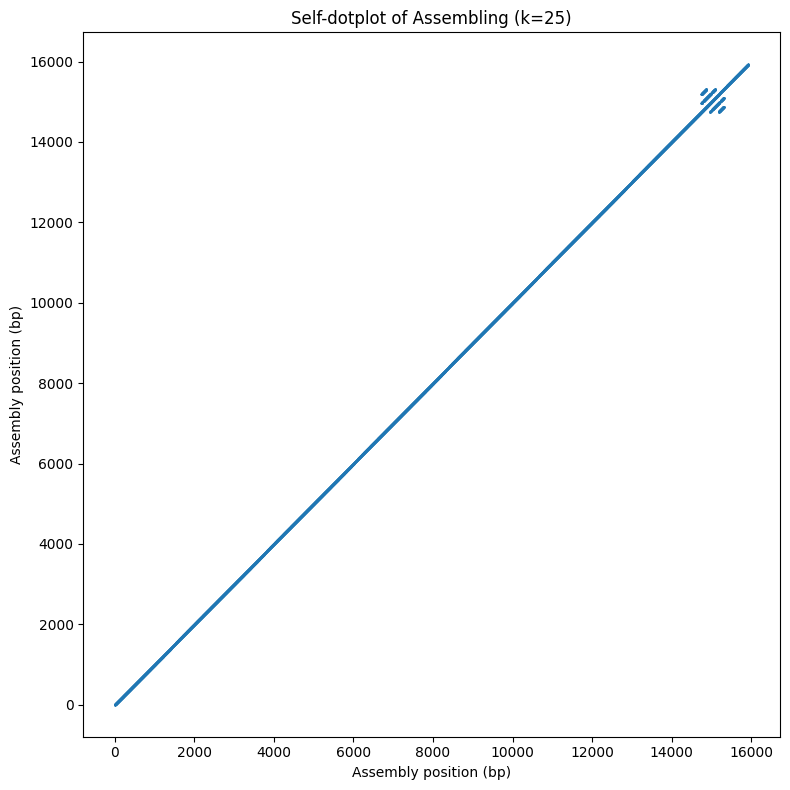

In [13]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt

# Input
assembly_file = "Assembled_gbima.fasta"
word_size = 25   # try 21, 25, 31; larger = cleaner, smaller = more sensitive
step = 1         # increase to 2 or 5 if you want faster but coarser results

# Read assembly
record = next(SeqIO.parse(assembly_file, "fasta"))
seq = str(record.seq).upper()
n = len(seq)

print(f"Assembly: {record.id}")
print(f"Length: {n} bp")
print(f"word_size: {word_size}")

# Index all k-mers in the sequence
kmer_positions = {}
for i in range(0, n - word_size + 1, step):
    kmer = seq[i:i+word_size]
    if "N" in kmer:
        continue
    kmer_positions.setdefault(kmer, []).append(i)

# Build dotplot points
x = []
y = []

for i in range(0, n - word_size + 1, step):
    kmer = seq[i:i+word_size]
    if "N" in kmer:
        continue
    matches = kmer_positions.get(kmer, [])
    for j in matches:
        x.append(i + 1)  # 1-based
        y.append(j + 1)

print(f"Dotplot points: {len(x)}")

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=0.2)
plt.xlabel("Assembly position (bp)")
plt.ylabel("Assembly position (bp)")
plt.title(f"Self-dotplot of {record.id} (k={word_size})")
plt.tight_layout()
plt.show()

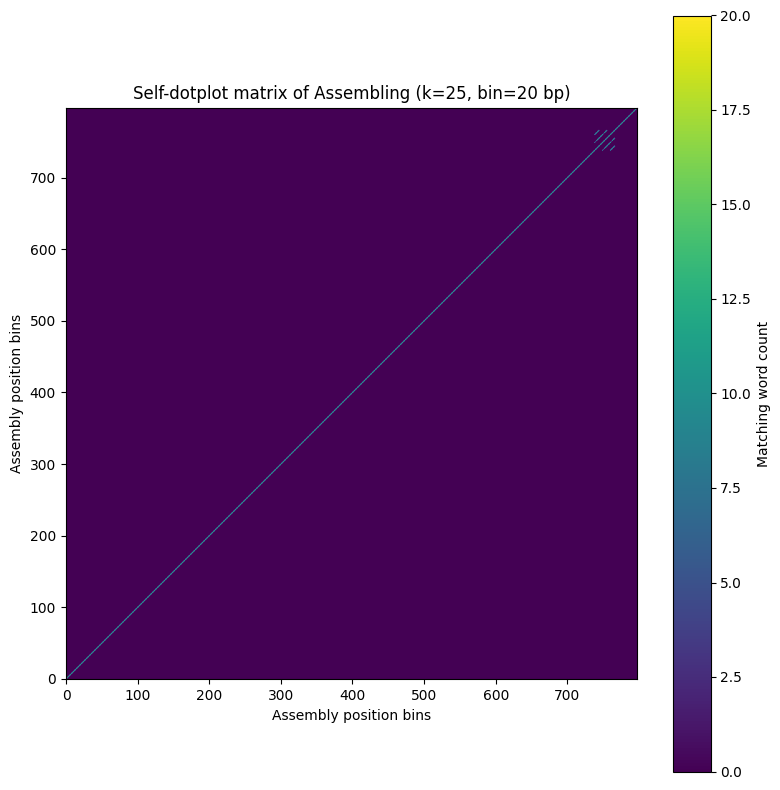

In [14]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt

assembly_file = "Assembled_gbima.fasta"
word_size = 25
bin_size = 20   # bp per pixel; smaller = higher resolution, larger = faster

record = next(SeqIO.parse(assembly_file, "fasta"))
seq = str(record.seq).upper()
n = len(seq)

nbins = (n + bin_size - 1) // bin_size
mat = np.zeros((nbins, nbins), dtype=np.uint16)

# index k-mers
kmer_positions = {}
for i in range(n - word_size + 1):
    kmer = seq[i:i+word_size]
    if "N" in kmer:
        continue
    kmer_positions.setdefault(kmer, []).append(i)

# fill matrix
for i in range(n - word_size + 1):
    kmer = seq[i:i+word_size]
    if "N" in kmer:
        continue
    xi = i // bin_size
    for j in kmer_positions[kmer]:
        yi = j // bin_size
        mat[yi, xi] += 1

plt.figure(figsize=(8, 8))
plt.imshow(mat, origin="lower", aspect="equal")
plt.xlabel("Assembly position bins")
plt.ylabel("Assembly position bins")
plt.title(f"Self-dotplot matrix of {record.id} (k={word_size}, bin={bin_size} bp)")
plt.colorbar(label="Matching word count")
plt.tight_layout()
plt.show()

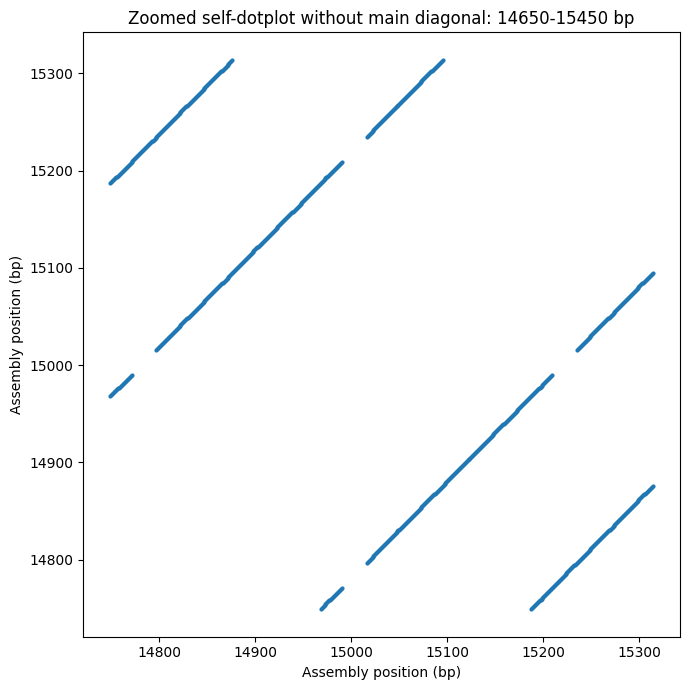

In [15]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt

assembly_file = "Assembled_gbima.fasta"
word_size = 25
start_bp = 14650
end_bp = 15450
diag_mask_bp = 40

record = next(SeqIO.parse(assembly_file, "fasta"))
seq = str(record.seq).upper()
subseq = seq[start_bp-1:end_bp]
n = len(subseq)

kmer_positions = {}
for i in range(n - word_size + 1):
    kmer = subseq[i:i+word_size]
    if "N" in kmer:
        continue
    kmer_positions.setdefault(kmer, []).append(i)

x, y = [], []
for i in range(n - word_size + 1):
    kmer = subseq[i:i+word_size]
    if "N" in kmer:
        continue
    for j in kmer_positions.get(kmer, []):
        if abs(i - j) > diag_mask_bp:
            x.append(start_bp + i)
            y.append(start_bp + j)

plt.figure(figsize=(7, 7))
plt.scatter(x, y, s=4)
plt.xlabel("Assembly position (bp)")
plt.ylabel("Assembly position (bp)")
plt.title(f"Zoomed self-dotplot without main diagonal: {start_bp}-{end_bp} bp")
plt.tight_layout()
plt.show()

In [16]:
from Bio import SeqIO
from collections import defaultdict, Counter

assembly_file = "Assembled_gbima.fasta"
k = 100

record = next(SeqIO.parse(assembly_file, "fasta"))
seq = str(record.seq).upper()

kmers = defaultdict(list)
for i in range(len(seq) - k + 1):
    kmers[seq[i:i+k]].append(i + 1)

repeat_spacings = []
for positions in kmers.values():
    if len(positions) > 1:
        positions = sorted(positions)
        for a in range(len(positions)):
            for b in range(a + 1, len(positions)):
                repeat_spacings.append(positions[b] - positions[a])

spacing_counts = Counter(repeat_spacings)

print("Most common repeat spacings:")
for spacing, count in spacing_counts.most_common(20):
    print(f"{spacing} bp: {count} repeated k-mers")

Most common repeat spacings:
219 bp: 124 repeated k-mers
438 bp: 53 repeated k-mers


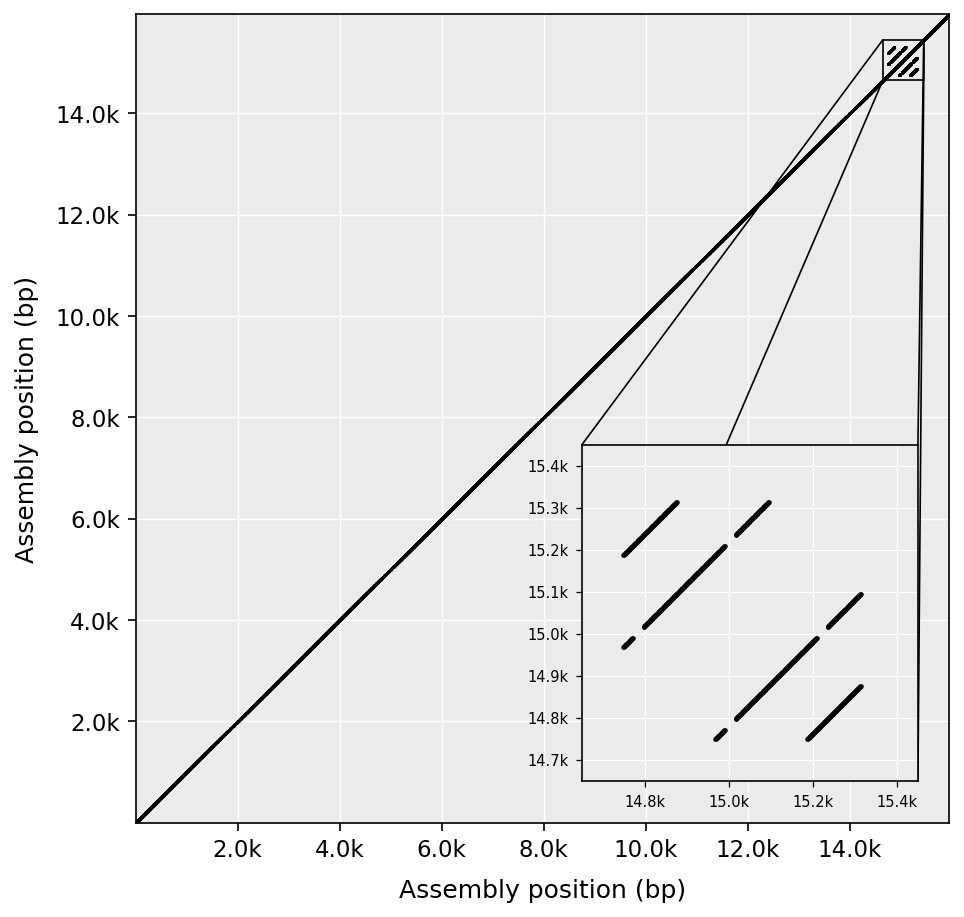

Saved: self_dotplot_with_inset.png


In [19]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import FancyBboxPatch, Rectangle, ConnectionPatch

assembly_file = "Assembled_gbima.fasta"
word_size = 25
step = 1

# Zoom region
zoom_start = 14650
zoom_end = 15450
diag_mask_bp = 40

record = next(SeqIO.parse(assembly_file, "fasta"))
seq = str(record.seq).upper()
n = len(seq)

# Index all k-mers
kmer_positions = {}
for i in range(0, n - word_size + 1, step):
    kmer = seq[i:i + word_size]
    if "N" in kmer:
        continue
    kmer_positions.setdefault(kmer, []).append(i)

# Collect all dotplot points
x_all, y_all = [], []
for i in range(0, n - word_size + 1, step):
    kmer = seq[i:i + word_size]
    if "N" in kmer:
        continue
    for j in kmer_positions.get(kmer, []):
        x_all.append(i + 1)
        y_all.append(j + 1)

x_all = np.array(x_all)
y_all = np.array(y_all)

# --- Publication-quality figure with inset ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

fig, ax = plt.subplots(figsize=(7, 7), dpi=150)
ax.set_facecolor('#EBEBEB')
ax.grid(True, color='white', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

# Main dotplot
ax.scatter(x_all, y_all, s=0.15, color='black', alpha=0.8, rasterized=True, zorder=2)
ax.set_xlabel("Assembly position (bp)", fontsize=12, labelpad=8)
ax.set_ylabel("Assembly position (bp)", fontsize=12, labelpad=8)
ax.set_xlim(1, n)
ax.set_ylim(1, n)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v/1000:.1f}k' if v >= 1000 else f'{v:.0f}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v/1000:.1f}k' if v >= 1000 else f'{v:.0f}'))

# Draw zoom rectangle on the main plot
rect = Rectangle((zoom_start, zoom_start), zoom_end - zoom_start, zoom_end - zoom_start,
                 linewidth=0.8, edgecolor='black', facecolor='none', zorder=4)
ax.add_patch(rect)

# --- Create inset axes manually for precise control ---
# Position: [left, bottom, width, height] in figure fraction
# Place inset in lower-right area
ax_inset = fig.add_axes([0.55, 0.15, 0.32, 0.32], zorder=10)
ax_inset.set_facecolor('#EBEBEB')
ax_inset.grid(True, color='white', linewidth=0.5, zorder=0)
ax_inset.set_axisbelow(True)

# Filter points within zoom window, off the main diagonal
mask = (
    (x_all >= zoom_start) & (x_all <= zoom_end) &
    (y_all >= zoom_start) & (y_all <= zoom_end) &
    (np.abs(x_all - y_all) > diag_mask_bp)
)
ax_inset.scatter(x_all[mask], y_all[mask], s=1.5, color='black', alpha=0.9, rasterized=True, zorder=2)
ax_inset.set_xlim(zoom_start, zoom_end)
ax_inset.set_ylim(zoom_start, zoom_end)
ax_inset.tick_params(labelsize=7, width=0.6, length=3)
ax_inset.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v/1000:.1f}k'))
ax_inset.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v/1000:.1f}k'))
for spine in ax_inset.spines.values():
    spine.set_linewidth(0.8)
    spine.set_zorder(12)

# --- Draw 4 connector lines from zoom rectangle corners to inset corners ---
# Zoom rectangle corners in main-axes data coordinates
rect_corners = {
    'bottom_left':  (zoom_start, zoom_start),
    'bottom_right': (zoom_end,   zoom_start),
    'top_left':     (zoom_start, zoom_end),
    'top_right':    (zoom_end,   zoom_end),
}
# Inset corners in inset-axes fraction coordinates (0–1)
inset_corners = {
    'bottom_left':  (0, 0),
    'bottom_right': (1, 0),
    'top_left':     (0, 1),
    'top_right':    (1, 1),
}

for corner in ['bottom_left', 'bottom_right', 'top_left', 'top_right']:
    con = ConnectionPatch(
        xyA=rect_corners[corner], coordsA=ax.transData,
        xyB=inset_corners[corner], coordsB=ax_inset.transAxes,
        color='black', linewidth=0.8, zorder=5,
    )
    fig.add_artist(con)

fig.savefig("self_dotplot_with_inset.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: self_dotplot_with_inset.png")